# Distributions

In [2]:
from empiricaldist import Pmf

coin = Pmf()
coin['heads'] = 1/2
coin['tails'] = 1/2
coin

,probs
heads,0.5
tails,0.5


In [3]:
die = Pmf.from_seq([1,2,3,4,5,6])
print(die)
print(die([1,4,7]))

1    0.166667
2    0.166667
3    0.166667
4    0.166667
5    0.166667
6    0.166667
Name: , dtype: float64
[0.16666667 0.16666667 0.        ]


In [4]:
letters = Pmf.from_seq(list('Mississippi'))
letters

,probs
M,0.090909
i,0.363636
p,0.181818
s,0.363636


In [5]:
print(letters(['s']))
print(letters(['t']))

[0.36363636]
[0.]


#### The Cookie Problem Revisited

In [6]:
prior = Pmf.from_seq(['Bowl 1', 'Bowl 2'])
prior

,probs
Bowl 1,0.5
Bowl 2,0.5


In [7]:
likelihood_vanilla = [0.75, 0.5]
posterior = prior * likelihood_vanilla
posterior

,probs
Bowl 1,0.375
Bowl 2,0.250


In [8]:
posterior.normalize()

np.float64(0.625)

In [9]:
posterior

,probs
Bowl 1,0.6
Bowl 2,0.4


In [10]:
posterior('Bowl 1')

np.float64(0.6)

Pmf objects makes sucessive updates easy when more data becomes available. Consider this example in which you place the cookie back and draw again from the same bowl, drawing a vanilla cookie again. 

In [11]:
posterior *= likelihood_vanilla
posterior.normalize()
posterior

,probs
Bowl 1,0.692308
Bowl 2,0.307692


Now imagine we do the same thing again but we draw a chocolate:

In [12]:
likelihood_chocolate = [0.25, 0.5]
posterior *= likelihood_chocolate
posterior.normalize()
posterior

,probs
Bowl 1,0.529412
Bowl 2,0.470588


#### 101 Cookie Bowls

- Bowl 0 contains 0% vanilla cookies / 100% chocolate cookies
- Bowl 1 contains 1% vanilla cookies / 99% chocolate cookies
...
- Bowl 99 contains 99% vanilla cookies / 1% chocolate cookies
- Bowl 100 contains 100% vanilla cookies / 0% chocolate cookies

In [13]:
import numpy as np
hypos = np.arange(101)

In [14]:
prior = Pmf(1, hypos)
prior.normalize()

np.int64(101)

In [15]:
# same prior probability before draw
prior.head()

,probs
0,0.009901
1,0.009901
2,0.009901


In [16]:
# the likelihood of the data is the fraction of the vanilla cookies in each bowl
likelihood_vanilla = hypos/100
likelihood_vanilla[:5]

array([0.  , 0.01, 0.02, 0.03, 0.04])

In [17]:
# now we can compute the posterior in the usual way
posterior1 = prior * likelihood_vanilla
posterior1.normalize()
posterior1.head()

,probs
0,0.000000
1,0.000198
2,0.000396


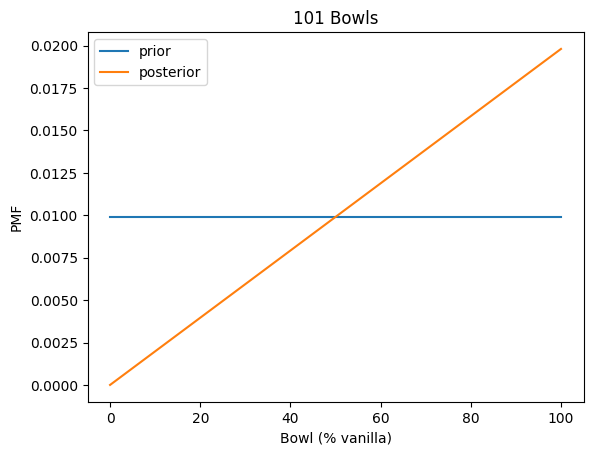

In [18]:
import matplotlib.pyplot as plt

# 101 cookie bowls: prior vs posterior after one vanilla draw
prior = Pmf(1, hypos)
prior.normalize()

posterior1 = prior * likelihood_vanilla
posterior1.normalize()

prior.plot(label='prior')
posterior1.plot(label='posterior')
plt.xlabel('Bowl (% vanilla)')
plt.ylabel('PMF')
plt.title('101 Bowls')
plt.legend()
plt.show()

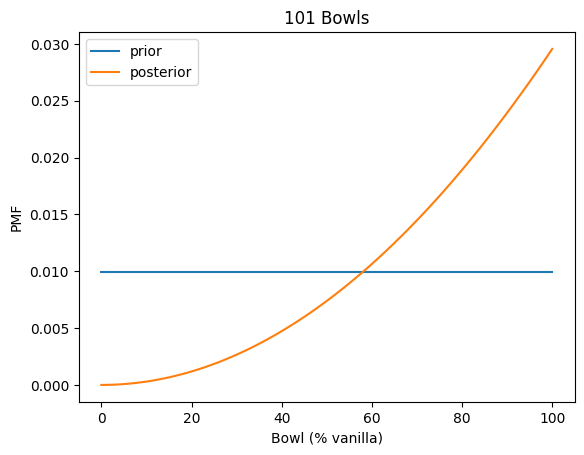

In [19]:
# Now imagine you place it back and draw another vanilla
posterior2 = posterior1 * likelihood_vanilla
posterior2.normalize()

prior.plot(label='prior')
posterior2.plot(label='posterior')
plt.xlabel('Bowl (% vanilla)')
plt.ylabel('PMF')
plt.title('101 Bowls')
plt.legend()
plt.show()

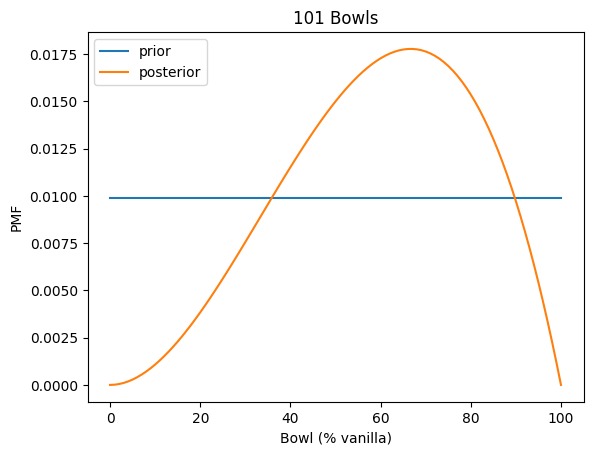

In [20]:
# Suppose you draw again and get a chocolate cookie
likelihood_chocolate = 1- hypos/100

posterior3 = posterior2 * likelihood_chocolate
posterior3.normalize()

prior.plot(label='prior')
posterior3.plot(label='posterior')
plt.xlabel('Bowl (% vanilla)')
plt.ylabel('PMF')
plt.title('101 Bowls')
plt.legend()
plt.show()

In [21]:
# find the bowl with the highest posterior probability

print(posterior3.idxmax())

# or use the Pmf function with a more memorable name
print(posterior3.max_prob())

67
67


#### The Dice problem

In [22]:
hypos = [6,8,12]
prior = Pmf(1/3, hypos)
prior

,probs
6,0.333333
8,0.333333
12,0.333333


In [23]:
print(prior.qs)
print(prior.ps)

[ 6  8 12]
[0.33333333 0.33333333 0.33333333]


In [24]:
likelihood1 = 1/6, 1/8, 1/12
posterior = prior * likelihood1
posterior.normalize()
posterior

,probs
6,0.444444
8,0.333333
12,0.222222


In [25]:
likelihood2 = 0, 1/8, 1/12
posterior *= likelihood2
posterior.normalize()
posterior

,probs
6,0.000000
8,0.692308
12,0.307692


#### Updating Dice

In [26]:
def update_dice(pmf, data):
    hypos = pmf.qs
    likelihood = 1/hypos
    impossible = (data > hypos)
    likelihood[impossible] = 0
    pmf *= likelihood
    pmf.normalize()

In [27]:
pmf = prior.copy()
pmf

,probs
6,0.333333
8,0.333333
12,0.333333


In [28]:
update_dice(pmf, 1)
update_dice(pmf, 7)
pmf

,probs
6,0.000000
8,0.692308
12,0.307692


#### Exercises

In [29]:
#3-1
def update_dice(pmf, data):
    hypos = pmf.qs
    likelihood = 1/hypos
    impossible = (data > hypos)
    likelihood[impossible] = 0
    pmf *= likelihood
    pmf.normalize()

update_dice(pmf, 1)
update_dice(pmf, 3)
update_dice(pmf, 5)
update_dice(pmf, 7)
pmf

,probs
6,0.000000
8,0.919294
12,0.080706


In [35]:
#3-2
hypos = [4, 6, 6, 8, 8, 8, 12, 12, 12, 12, 20, 20, 20, 20, 20]
prior = Pmf(1/15, hypos)
print(prior)

def update_dice(pmf, data):
    hypos = pmf.qs
    likelihood = 1/hypos
    impossible = (data > hypos)
    likelihood[impossible] = 0
    pmf *= likelihood
    pmf.normalize()

pmf = prior.copy()
update_dice(pmf, 7)
print(pmf)

pmf[8].sum()

4     0.066667
6     0.066667
6     0.066667
8     0.066667
8     0.066667
8     0.066667
12    0.066667
12    0.066667
12    0.066667
12    0.066667
20    0.066667
20    0.066667
20    0.066667
20    0.066667
20    0.066667
dtype: float64
4     0.000000
6     0.000000
6     0.000000
8     0.130435
8     0.130435
8     0.130435
12    0.086957
12    0.086957
12    0.086957
12    0.086957
20    0.052174
20    0.052174
20    0.052174
20    0.052174
20    0.052174
dtype: float64


np.float64(0.3913043478260869)

In [38]:
#3-3
prior = Pmf.from_seq(['drawer 1', 'drawer 2'])
likelihood_matching_pair = [1/2, 1/3]      # match probability per drawer
posterior_drawer = prior * likelihood_matching_pair
posterior_drawer.normalize()

p_white = posterior_drawer['drawer 1'] * (1/2)   # only drawer 1 can produce white, and it's half its matches
p_white

np.float64(0.30000000000000004)